# PyTorch 기반 은행 대출 상환/채무불이행 분류 실습

이 노트북은 Google Colab에서 실행 가능한 **PyTorch 코드**로 구현한 것입니다.

의사결정트리를 사용하여 은행 대출 신청자의 채무불이행 여부를 분류합니다.  
같은 분류 문제를 PyTorch의 신경망 분류 모델로 구현합니다.

## 전체 흐름

1. 필요한 라이브러리 설치 및 불러오기  
2. 데이터셋 준비  
3. 데이터 탐색  
4. 범주형/수치형 데이터 전처리  
5. 학습 데이터와 테스트 데이터 분리  
6. PyTorch Dataset / DataLoader 생성  
7. PyTorch 분류 모델 정의  
8. 모델 학습  
9. 테스트 데이터 예측  
10. Confusion Matrix와 정확도 평가


In [1]:
# ============================================================
# 1. 필요한 라이브러리 불러오기
# ============================================================

# pandas는 CSV 파일을 읽고 표 형태의 데이터를 다루기 위한 라이브러리입니다.
import pandas as pd

# numpy는 숫자 배열 계산을 빠르게 처리하기 위한 라이브러리입니다.
import numpy as np

# torch는 PyTorch의 핵심 라이브러리입니다.
# 텐서 생성, 신경망 학습, 자동 미분 등을 처리합니다.
import torch

# torch.nn은 신경망 계층, 손실 함수 등을 만들 때 사용하는 모듈입니다.
import torch.nn as nn

# torch.optim은 Adam, SGD 같은 최적화 알고리즘을 제공하는 모듈입니다.
import torch.optim as optim

# Dataset과 DataLoader는 데이터를 PyTorch 모델에 넣기 좋은 형태로 관리하는 도구입니다.
from torch.utils.data import Dataset, DataLoader

# train_test_split은 데이터를 학습용과 테스트용으로 나누는 함수입니다.
from sklearn.model_selection import train_test_split

# ColumnTransformer는 수치형/범주형 컬럼에 서로 다른 전처리를 적용할 때 사용합니다.
from sklearn.compose import ColumnTransformer

# OneHotEncoder는 문자 범주 데이터를 0과 1의 숫자 벡터로 변환합니다.
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

# Pipeline은 여러 전처리 단계를 하나로 묶어 실행할 때 사용합니다.
from sklearn.pipeline import Pipeline

# accuracy_score와 confusion_matrix는 모델 평가 지표를 계산합니다.
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# matplotlib은 그래프를 그리기 위한 라이브러리입니다.
import matplotlib.pyplot as plt

# random은 파이썬의 난수 생성을 제어할 때 사용합니다.
import random

# os는 파일 경로 확인 등에 사용합니다.
import os

# 경고 메시지를 줄여 출력 화면을 깔끔하게 만들기 위해 사용합니다.
import warnings

# 불필요한 경고 메시지를 숨깁니다.
warnings.filterwarnings("ignore")

# 현재 사용 가능한 장치를 확인합니다.
# Colab에서 GPU를 켜면 cuda가 출력되고, 그렇지 않으면 cpu가 출력됩니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 현재 학습에 사용할 장치를 출력합니다.
print("사용 장치:", device)


사용 장치: cuda


In [2]:
# ============================================================
# 2. 난수 고정
# ============================================================

# 난수를 고정하면 코드를 다시 실행해도 최대한 같은 결과가 나오도록 만들 수 있습니다.
SEED = 123

# 파이썬 random 라이브러리의 난수를 고정합니다.
random.seed(SEED)

# numpy 난수를 고정합니다.
np.random.seed(SEED)

# PyTorch CPU 연산의 난수를 고정합니다.
torch.manual_seed(SEED)

# PyTorch GPU 연산의 난수를 고정합니다.
torch.cuda.manual_seed_all(SEED)

# CUDA 연산의 재현성을 높이기 위한 설정입니다.
torch.backends.cudnn.deterministic = True

# 실행 속도 최적화보다 재현성을 우선하도록 설정합니다.
torch.backends.cudnn.benchmark = False


## 3. 데이터셋 준비

다음 파일을 사용합니다.

```r
credit_info <- read.csv("data/credit_info.csv", stringsAsFactors = T)
```

Colab에서는 로컬 파일이 없을 수 있으므로 다음 순서로 데이터를 준비합니다.

1. `data/credit_info.csv`가 있으면 그 파일을 사용  
2. 없으면 공개 German Credit 데이터셋 CSV를 자동 다운로드  
3. 목표 컬럼이 `default`로 되어 있으면 `Repay`로 이름을 바꾸어 원본 코드와 비슷하게 맞춤


In [3]:
# ============================================================
# 3. 데이터 불러오기
# ============================================================

# 사용한 파일 경로입니다.
local_path = "data/credit_info.csv"

# 공개 German Credit 데이터셋 주소입니다.
# Colab에서 data/credit_info.csv 파일이 없을 때 자동으로 읽어옵니다.
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/credit.csv"

# data 폴더가 없으면 새로 생성합니다.
os.makedirs("data", exist_ok=True)

# local_path 파일이 실제로 존재하는지 확인합니다.
if os.path.exists(local_path):
    # 파일이 있으면 사용자가 제공한 로컬 CSV 파일을 읽습니다.
    credit_info = pd.read_csv(local_path)
else:
    # 파일이 없으면 공개 URL에서 CSV 파일을 읽습니다.
    credit_info = pd.read_csv(url)

    # 다음 실행 때도 같은 파일을 사용할 수 있도록 data 폴더에 저장합니다.
    credit_info.to_csv(local_path, index=False)

# 목표 변수를 Repay라고 사용합니다.
# 공개 데이터셋은 목표 컬럼명이 default일 수 있으므로 Repay로 바꿉니다.
if "Repay" not in credit_info.columns and "default" in credit_info.columns:
    # default 컬럼명을 Repay로 변경합니다.
    credit_info = credit_info.rename(columns={"default": "Repay"})

# 데이터의 앞부분 5행을 확인합니다.
credit_info.head()


,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_length,installment_rate,personal_status,other_debtors,...,property,age,installment_plan,housing,existing_credits,Repay,dependents,telephone,foreign_worker,job
0,< 0 DM,6,critical,radio/tv,1169,unknown,> 7 yrs,4,single male,none,...,real estate,67,none,own,2,1,1,yes,yes,skilled employee
1,1 - 200 DM,48,repaid,radio/tv,5951,< 100 DM,1 - 4 yrs,2,female,none,...,real estate,22,none,own,1,2,1,none,yes,skilled employee
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 yrs,2,single male,none,...,real estate,49,none,own,1,1,2,none,yes,unskilled resident
3,< 0 DM,42,repaid,furniture,7882,< 100 DM,4 - 7 yrs,2,single male,guarantor,...,building society savings,45,none,for free,1,1,2,none,yes,skilled employee
4,< 0 DM,24,delayed,car (new),4870,< 100 DM,1 - 4 yrs,3,single male,none,...,unknown/none,53,none,for free,2,2,2,none,yes,skilled employee


In [4]:
# ============================================================
# 4. 데이터 구조 확인
# ============================================================

# 데이터의 행과 열 개수를 확인합니다.
print("데이터 크기:", credit_info.shape)

# 각 컬럼의 자료형과 결측치 여부를 확인합니다.
credit_info.info()

# 컬럼 이름 목록을 출력합니다.
print("\n컬럼 목록:")
print(credit_info.columns.tolist())


데이터 크기: (1000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   checking_balance      1000 non-null   object
 1   months_loan_duration  1000 non-null   int64 
 2   credit_history        1000 non-null   object
 3   purpose               1000 non-null   object
 4   amount                1000 non-null   int64 
 5   savings_balance       1000 non-null   object
 6   employment_length     1000 non-null   object
 7   installment_rate      1000 non-null   int64 
 8   personal_status       1000 non-null   object
 9   other_debtors         1000 non-null   object
 10  residence_history     1000 non-null   int64 
 11  property              1000 non-null   object
 12  age                   1000 non-null   int64 
 13  installment_plan      1000 non-null   object
 14  housing               1000 non-null   object
 15  existing_credits    

In [5]:
# ============================================================
# 5. 기본 탐색
# ============================================================

# checking_balance 컬럼은 신청자의 수표 계좌 잔고 범주를 의미합니다.
# value_counts()는 R의 table()과 비슷하게 값별 개수를 세어 줍니다.
print("checking_balance 빈도:")
print(credit_info["checking_balance"].value_counts())

# savings_balance 컬럼은 신청자의 저축 계좌 잔고 범주를 의미합니다.
print("\nsavings_balance 빈도:")
print(credit_info["savings_balance"].value_counts())

# months_loan_duration은 대출 기간입니다.
# describe()는 평균, 표준편차, 최솟값, 최댓값 등을 보여줍니다.
print("\nmonths_loan_duration 요약:")
print(credit_info["months_loan_duration"].describe())

# amount는 대출 금액입니다.
print("\namount 요약:")
print(credit_info["amount"].describe())

# Repay는 상환 여부 또는 채무불이행 여부를 나타내는 목표 변수입니다.
print("\nRepay 빈도:")
print(credit_info["Repay"].value_counts())

# Repay 비율을 확인합니다.
print("\nRepay 비율:")
print(credit_info["Repay"].value_counts(normalize=True))


checking_balance 빈도:
checking_balance
unknown       394
< 0 DM        274
1 - 200 DM    269
> 200 DM       63
Name: count, dtype: int64

savings_balance 빈도:
savings_balance
< 100 DM         603
unknown          183
101 - 500 DM     103
501 - 1000 DM     63
> 1000 DM         48
Name: count, dtype: int64

months_loan_duration 요약:
count    1000.000000
mean       20.903000
std        12.058814
min         4.000000
25%        12.000000
50%        18.000000
75%        24.000000
max        72.000000
Name: months_loan_duration, dtype: float64

amount 요약:
count     1000.000000
mean      3271.258000
std       2822.736876
min        250.000000
25%       1365.500000
50%       2319.500000
75%       3972.250000
max      18424.000000
Name: amount, dtype: float64

Repay 빈도:
Repay
1    700
2    300
Name: count, dtype: int64

Repay 비율:
Repay
1    0.7
2    0.3
Name: proportion, dtype: float64


## 6. 입력 데이터와 정답 데이터 분리

- `X`: 모델이 학습할 입력 특성  
- `y`: 모델이 맞혀야 하는 정답 라벨  

`credit_info_train[-17]`로 마지막 목표 컬럼을 제외했습니다.  
여기서는 컬럼 이름 `Repay`를 기준으로 입력과 정답을 분리합니다.


In [6]:
# ============================================================
# 6. 입력 X와 정답 y 분리
# ============================================================

# 목표 컬럼명을 변수로 저장합니다.
target_col = "Repay"

# 목표 컬럼이 실제 데이터에 있는지 확인합니다.
if target_col not in credit_info.columns:
    # 목표 컬럼이 없으면 에러를 발생시켜 문제 원인을 바로 알 수 있게 합니다.
    raise ValueError("데이터에 Repay 컬럼이 없습니다. 목표 컬럼명을 확인하세요.")

# X는 Repay를 제외한 모든 컬럼입니다.
X = credit_info.drop(columns=[target_col])

# y는 모델이 예측해야 하는 Repay 컬럼입니다.
y = credit_info[target_col]

# LabelEncoder는 문자 라벨을 숫자 라벨로 바꿉니다.
# 예: no -> 0, yes -> 1 과 같은 방식입니다.
label_encoder = LabelEncoder()

# y 값을 숫자 형태로 변환합니다.
y_encoded = label_encoder.fit_transform(y)

# 어떤 원래 라벨이 어떤 숫자로 바뀌었는지 확인합니다.
print("라벨 매핑:")
for original_label, encoded_label in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"{original_label} -> {encoded_label}")


라벨 매핑:
1 -> 0
2 -> 1


In [7]:
# ============================================================
# 7. 수치형 컬럼과 범주형 컬럼 구분
# ============================================================

# 수치형 컬럼은 int64, float64 같은 숫자 자료형 컬럼입니다.
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# 범주형 컬럼은 object, category 같은 문자 또는 범주 자료형 컬럼입니다.
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# 수치형 컬럼 목록을 출력합니다.
print("수치형 컬럼:", numeric_features)

# 범주형 컬럼 목록을 출력합니다.
print("범주형 컬럼:", categorical_features)


수치형 컬럼: ['months_loan_duration', 'amount', 'installment_rate', 'residence_history', 'age', 'existing_credits', 'dependents']
범주형 컬럼: ['checking_balance', 'credit_history', 'purpose', 'savings_balance', 'employment_length', 'personal_status', 'other_debtors', 'property', 'installment_plan', 'housing', 'telephone', 'foreign_worker', 'job']


In [8]:
# ============================================================
# 8. 학습 데이터와 테스트 데이터 분리
# ============================================================

# train_test_split은 데이터를 학습용과 테스트용으로 나눕니다.
# test_size=0.2는 전체 데이터의 20%를 테스트용으로 사용한다는 뜻입니다.
# 800개 학습 / 200개 테스트 분리와 같은 비율입니다.
# stratify=y_encoded는 정답 라벨 비율이 학습/테스트에 비슷하게 유지되도록 합니다.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=SEED,
    stratify=y_encoded
)

# 분리된 데이터 크기를 확인합니다.
print("X_train 크기:", X_train.shape)
print("X_test 크기:", X_test.shape)
print("y_train 크기:", y_train.shape)
print("y_test 크기:", y_test.shape)

# 학습 데이터의 클래스 비율을 확인합니다.
print("\n학습 데이터 클래스 비율:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())

# 테스트 데이터의 클래스 비율을 확인합니다.
print("\n테스트 데이터 클래스 비율:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index())


X_train 크기: (800, 20)
X_test 크기: (200, 20)
y_train 크기: (800,)
y_test 크기: (200,)

학습 데이터 클래스 비율:
0    0.7
1    0.3
Name: proportion, dtype: float64

테스트 데이터 클래스 비율:
0    0.7
1    0.3
Name: proportion, dtype: float64


## 7. 데이터 전처리

PyTorch 모델은 숫자 텐서만 입력으로 받을 수 있습니다.

따라서 다음 전처리를 수행합니다.

- 수치형 컬럼: 평균 0, 표준편차 1에 가깝도록 표준화  
- 범주형 컬럼: One-Hot Encoding으로 0/1 숫자 벡터 변환


In [9]:
# ============================================================
# 9. 전처리 파이프라인 생성
# ============================================================

# 수치형 데이터 전처리: StandardScaler로 표준화합니다.
numeric_transformer = Pipeline(
    steps=[
        # StandardScaler는 수치 데이터의 크기 차이를 줄여 학습을 안정적으로 만듭니다.
        ("scaler", StandardScaler())
    ]
)

# 범주형 데이터 전처리: OneHotEncoder로 숫자 벡터화합니다.
categorical_transformer = Pipeline(
    steps=[
        # handle_unknown="ignore"는 테스트 데이터에 학습 때 보지 못한 범주가 나와도 에러를 막습니다.
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# ColumnTransformer는 컬럼 종류별로 다른 전처리를 적용합니다.
preprocessor = ColumnTransformer(
    transformers=[
        # numeric_features 컬럼에는 numeric_transformer를 적용합니다.
        ("num", numeric_transformer, numeric_features),

        # categorical_features 컬럼에는 categorical_transformer를 적용합니다.
        ("cat", categorical_transformer, categorical_features)
    ]
)

# fit_transform은 학습 데이터 기준으로 전처리 규칙을 학습하고 바로 변환합니다.
X_train_processed = preprocessor.fit_transform(X_train)

# transform은 학습 데이터에서 만든 규칙을 테스트 데이터에 그대로 적용합니다.
X_test_processed = preprocessor.transform(X_test)

# OneHotEncoder 결과가 희소 행렬일 수 있으므로 일반 numpy 배열로 변환합니다.
X_train_processed = X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed
X_test_processed = X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed

# PyTorch는 float32 자료형을 주로 사용하므로 float32로 변환합니다.
X_train_processed = X_train_processed.astype(np.float32)
X_test_processed = X_test_processed.astype(np.float32)

# 정답 라벨은 분류 문제에서 long 타입으로 사용합니다.
y_train = y_train.astype(np.int64)
y_test = y_test.astype(np.int64)

# 전처리 후 입력 특성 개수를 확인합니다.
print("전처리 후 학습 입력 크기:", X_train_processed.shape)
print("전처리 후 테스트 입력 크기:", X_test_processed.shape)


전처리 후 학습 입력 크기: (800, 61)
전처리 후 테스트 입력 크기: (200, 61)


## 8. PyTorch Dataset과 DataLoader 생성

`Dataset`은 데이터를 한 개씩 꺼내는 방법을 정의합니다.  
`DataLoader`는 데이터를 미니배치 단위로 모델에 공급합니다.


In [10]:
# ============================================================
# 10. PyTorch Dataset 클래스 정의
# ============================================================

# CreditDataset은 대출 데이터를 PyTorch가 사용할 수 있는 형태로 포장하는 클래스입니다.
class CreditDataset(Dataset):
    # __init__은 Dataset 객체가 만들어질 때 한 번 실행됩니다.
    def __init__(self, features, labels):
        # 입력 특성을 torch 텐서로 변환합니다.
        self.features = torch.tensor(features, dtype=torch.float32)

        # 정답 라벨을 torch 텐서로 변환합니다.
        self.labels = torch.tensor(labels, dtype=torch.long)

    # __len__은 데이터가 총 몇 개인지 반환합니다.
    def __len__(self):
        # labels의 길이가 전체 데이터 개수입니다.
        return len(self.labels)

    # __getitem__은 특정 번호의 데이터 1개를 반환합니다.
    def __getitem__(self, idx):
        # idx번째 입력 데이터와 정답 라벨을 함께 반환합니다.
        return self.features[idx], self.labels[idx]


# 학습용 Dataset 객체를 생성합니다.
train_dataset = CreditDataset(X_train_processed, y_train)

# 테스트용 Dataset 객체를 생성합니다.
test_dataset = CreditDataset(X_test_processed, y_test)

# 한 번에 학습할 데이터 개수입니다.
# 32개씩 묶어서 모델에 넣습니다.
batch_size = 32

# 학습용 DataLoader를 생성합니다.
# shuffle=True는 매 epoch마다 데이터 순서를 섞어 학습 효과를 높입니다.
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 테스트용 DataLoader를 생성합니다.
# 테스트는 순서를 섞을 필요가 없으므로 shuffle=False입니다.
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 첫 번째 미니배치를 꺼내 입력과 정답 크기를 확인합니다.
sample_X, sample_y = next(iter(train_loader))

# 미니배치 입력 크기를 출력합니다.
print("미니배치 입력 크기:", sample_X.shape)

# 미니배치 정답 크기를 출력합니다.
print("미니배치 정답 크기:", sample_y.shape)


미니배치 입력 크기: torch.Size([32, 61])
미니배치 정답 크기: torch.Size([32])


## 9. PyTorch 분류 모델 정의

코드는 C5.0 의사결정트리를 사용했습니다.  
여기서는 PyTorch의 기본 신경망인 MLP, 즉 다층 퍼셉트론을 사용합니다.

구조:

- 입력층: 전처리 후 특성 개수  
- 은닉층 1: 64개 뉴런  
- 은닉층 2: 32개 뉴런  
- 출력층: 클래스 개수  


In [11]:
# ============================================================
# 11. PyTorch 모델 정의
# ============================================================

# CreditMLP는 대출 상환 여부를 분류하는 신경망 모델입니다.
class CreditMLP(nn.Module):
    # __init__은 모델 구조를 정의하는 부분입니다.
    def __init__(self, input_dim, num_classes):
        # 부모 클래스 nn.Module의 초기화 함수를 실행합니다.
        super(CreditMLP, self).__init__()

        # self.network는 여러 신경망 계층을 순서대로 묶은 구조입니다.
        self.network = nn.Sequential(
            # 첫 번째 완전연결층입니다.
            # input_dim개의 입력을 받아 64개의 값으로 변환합니다.
            nn.Linear(input_dim, 64),

            # ReLU는 음수는 0으로, 양수는 그대로 통과시키는 활성화 함수입니다.
            # 모델이 복잡한 패턴을 학습할 수 있게 도와줍니다.
            nn.ReLU(),

            # Dropout은 일부 뉴런을 무작위로 끄는 기법입니다.
            # 과적합을 줄이는 데 도움이 됩니다.
            nn.Dropout(0.2),

            # 두 번째 완전연결층입니다.
            # 64개의 입력을 받아 32개의 값으로 변환합니다.
            nn.Linear(64, 32),

            # 두 번째 ReLU 활성화 함수입니다.
            nn.ReLU(),

            # 마지막 출력층입니다.
            # 32개의 입력을 클래스 개수만큼의 점수로 변환합니다.
            nn.Linear(32, num_classes)
        )

    # forward는 입력 데이터가 모델을 통과하는 계산 과정을 정의합니다.
    def forward(self, x):
        # 입력 x를 self.network에 통과시켜 출력값을 만듭니다.
        return self.network(x)


# 입력 특성 개수입니다.
input_dim = X_train_processed.shape[1]

# 분류할 클래스 개수입니다.
num_classes = len(label_encoder.classes_)

# 모델 객체를 생성하고 학습 장치(cpu 또는 cuda)로 이동합니다.
model = CreditMLP(input_dim=input_dim, num_classes=num_classes).to(device)

# 모델 구조를 출력합니다.
print(model)


CreditMLP(
  (network): Sequential(
    (0): Linear(in_features=61, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [12]:
# ============================================================
# 12. 손실 함수와 최적화 알고리즘 설정
# ============================================================

# CrossEntropyLoss는 다중 분류 문제에서 많이 사용하는 손실 함수입니다.
# 모델의 예측이 정답과 얼마나 다른지 숫자로 계산합니다.
criterion = nn.CrossEntropyLoss()

# Adam은 학습률을 자동으로 조정해 가며 모델 파라미터를 업데이트하는 최적화 알고리즘입니다.
optimizer = optim.Adam(
    model.parameters(),  # 학습할 모델 파라미터를 지정합니다.
    lr=0.001             # learning rate, 즉 한 번에 얼마나 크게 수정할지 정합니다.
)


## 10. 모델 학습

아래 코드는 epoch마다 다음 값을 출력합니다.

- 학습 손실값  
- 학습 정확도  
- 테스트 손실값  
- 테스트 정확도  

손실값은 낮을수록 좋고, 정확도는 높을수록 좋습니다.


In [13]:
# ============================================================
# 13. 평가 함수 정의
# ============================================================

# evaluate 함수는 검증 또는 테스트 데이터에서 모델 성능을 계산합니다.
def evaluate(model, data_loader, criterion):
    # 모델을 평가 모드로 바꿉니다.
    # Dropout 같은 학습 전용 동작이 꺼집니다.
    model.eval()

    # 전체 손실값을 누적할 변수입니다.
    total_loss = 0.0

    # 맞힌 개수를 누적할 변수입니다.
    correct = 0

    # 전체 데이터 개수를 누적할 변수입니다.
    total = 0

    # 평가할 때는 기울기 계산이 필요 없으므로 no_grad를 사용합니다.
    with torch.no_grad():
        # DataLoader에서 미니배치 단위로 데이터를 꺼냅니다.
        for batch_X, batch_y in data_loader:
            # 입력 데이터를 학습 장치로 이동합니다.
            batch_X = batch_X.to(device)

            # 정답 라벨을 학습 장치로 이동합니다.
            batch_y = batch_y.to(device)

            # 모델에 입력 데이터를 넣어 예측 점수를 계산합니다.
            outputs = model(batch_X)

            # 예측 점수와 정답 사이의 손실값을 계산합니다.
            loss = criterion(outputs, batch_y)

            # 현재 미니배치 손실값에 데이터 개수를 곱해 누적합니다.
            total_loss += loss.item() * batch_X.size(0)

            # 가장 점수가 높은 클래스 번호를 예측값으로 선택합니다.
            _, predicted = torch.max(outputs, 1)

            # 전체 데이터 개수를 누적합니다.
            total += batch_y.size(0)

            # 예측값과 정답이 같은 개수를 누적합니다.
            correct += (predicted == batch_y).sum().item()

    # 평균 손실값을 계산합니다.
    avg_loss = total_loss / total

    # 정확도를 계산합니다.
    accuracy = correct / total

    # 평균 손실값과 정확도를 반환합니다.
    return avg_loss, accuracy


In [14]:
# ============================================================
# 14. 모델 학습 실행
# ============================================================

# 전체 학습 반복 횟수입니다.
epochs = 50

# 학습 과정을 저장할 리스트입니다.
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

# epoch 수만큼 반복 학습합니다.
for epoch in range(epochs):
    # 모델을 학습 모드로 바꿉니다.
    # Dropout 같은 학습 전용 동작이 켜집니다.
    model.train()

    # 한 epoch 동안의 손실값을 누적할 변수입니다.
    running_loss = 0.0

    # 한 epoch 동안 맞힌 개수를 누적할 변수입니다.
    correct = 0

    # 한 epoch 동안 전체 데이터 개수를 누적할 변수입니다.
    total = 0

    # 학습 데이터를 미니배치 단위로 반복합니다.
    for batch_X, batch_y in train_loader:
        # 입력 데이터를 학습 장치로 이동합니다.
        batch_X = batch_X.to(device)

        # 정답 라벨을 학습 장치로 이동합니다.
        batch_y = batch_y.to(device)

        # 이전 미니배치에서 계산된 기울기를 초기화합니다.
        optimizer.zero_grad()

        # 모델에 입력 데이터를 넣어 예측 점수를 계산합니다.
        outputs = model(batch_X)

        # 예측 결과와 실제 정답 사이의 손실값을 계산합니다.
        loss = criterion(outputs, batch_y)

        # 손실값을 기준으로 각 파라미터의 기울기를 계산합니다.
        loss.backward()

        # 계산된 기울기를 사용하여 모델 파라미터를 업데이트합니다.
        optimizer.step()

        # 현재 미니배치 손실값을 누적합니다.
        running_loss += loss.item() * batch_X.size(0)

        # 가장 큰 점수를 가진 클래스를 예측값으로 선택합니다.
        _, predicted = torch.max(outputs, 1)

        # 전체 데이터 개수를 누적합니다.
        total += batch_y.size(0)

        # 예측값과 정답이 같은 개수를 누적합니다.
        correct += (predicted == batch_y).sum().item()

    # 한 epoch의 평균 학습 손실값을 계산합니다.
    train_loss = running_loss / total

    # 한 epoch의 학습 정확도를 계산합니다.
    train_acc = correct / total

    # 테스트 데이터에 대한 손실값과 정확도를 계산합니다.
    test_loss, test_acc = evaluate(model, test_loader, criterion)

    # 그래프 출력을 위해 값을 리스트에 저장합니다.
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    # epoch마다 학습 결과를 출력합니다.
    print(
        f"Epoch [{epoch + 1:02d}/{epochs}] "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
        f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}"
    )


Epoch [01/50] Train Loss: 0.6646, Train Acc: 0.6225, Test Loss: 0.6253, Test Acc: 0.7000
Epoch [02/50] Train Loss: 0.6024, Train Acc: 0.7000, Test Loss: 0.5898, Test Acc: 0.7000
Epoch [03/50] Train Loss: 0.5727, Train Acc: 0.7000, Test Loss: 0.5627, Test Acc: 0.7000
Epoch [04/50] Train Loss: 0.5363, Train Acc: 0.7087, Test Loss: 0.5311, Test Acc: 0.7200
Epoch [05/50] Train Loss: 0.4933, Train Acc: 0.7438, Test Loss: 0.5095, Test Acc: 0.7300
Epoch [06/50] Train Loss: 0.4678, Train Acc: 0.7725, Test Loss: 0.5125, Test Acc: 0.7200
Epoch [07/50] Train Loss: 0.4464, Train Acc: 0.7937, Test Loss: 0.5173, Test Acc: 0.7400
Epoch [08/50] Train Loss: 0.4260, Train Acc: 0.8025, Test Loss: 0.5204, Test Acc: 0.7350
Epoch [09/50] Train Loss: 0.4101, Train Acc: 0.8037, Test Loss: 0.5259, Test Acc: 0.7100
Epoch [10/50] Train Loss: 0.3946, Train Acc: 0.8137, Test Loss: 0.5346, Test Acc: 0.7050
Epoch [11/50] Train Loss: 0.3865, Train Acc: 0.8225, Test Loss: 0.5374, Test Acc: 0.7250
Epoch [12/50] Train L

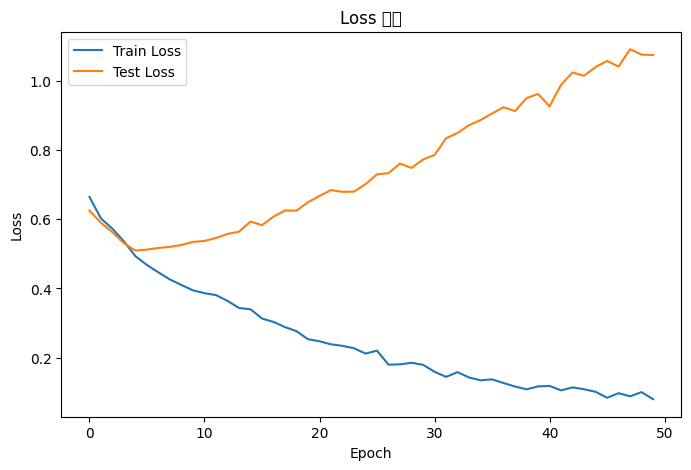

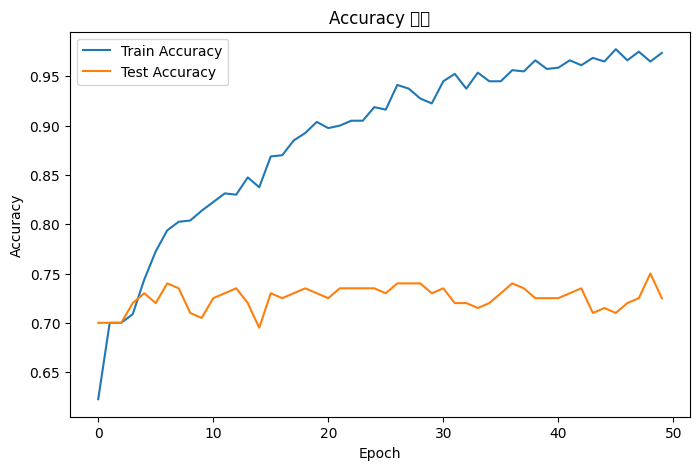

In [15]:
# ============================================================
# 15. 학습 과정 그래프 출력
# ============================================================

# 그래프 크기를 지정합니다.
plt.figure(figsize=(8, 5))

# 학습 손실값 변화를 선 그래프로 표시합니다.
plt.plot(train_losses, label="Train Loss")

# 테스트 손실값 변화를 선 그래프로 표시합니다.
plt.plot(test_losses, label="Test Loss")

# 그래프 제목을 지정합니다.
plt.title("Loss 변화")

# x축 이름을 지정합니다.
plt.xlabel("Epoch")

# y축 이름을 지정합니다.
plt.ylabel("Loss")

# 범례를 표시합니다.
plt.legend()

# 그래프를 출력합니다.
plt.show()

# 새로운 그래프 크기를 지정합니다.
plt.figure(figsize=(8, 5))

# 학습 정확도 변화를 선 그래프로 표시합니다.
plt.plot(train_accuracies, label="Train Accuracy")

# 테스트 정확도 변화를 선 그래프로 표시합니다.
plt.plot(test_accuracies, label="Test Accuracy")

# 그래프 제목을 지정합니다.
plt.title("Accuracy 변화")

# x축 이름을 지정합니다.
plt.xlabel("Epoch")

# y축 이름을 지정합니다.
plt.ylabel("Accuracy")

# 범례를 표시합니다.
plt.legend()

# 그래프를 출력합니다.
plt.show()


## 11. 테스트 데이터 예측 및 성능 평가

Python에서는 `confusion_matrix()`로 수행합니다.


In [16]:
# ============================================================
# 16. 테스트 데이터 전체 예측
# ============================================================

# 모델을 평가 모드로 변경합니다.
model.eval()

# 예측값을 저장할 리스트입니다.
all_predictions = []

# 실제 정답을 저장할 리스트입니다.
all_labels = []

# 테스트 과정에서는 기울기 계산이 필요 없으므로 no_grad를 사용합니다.
with torch.no_grad():
    # 테스트 데이터를 미니배치 단위로 반복합니다.
    for batch_X, batch_y in test_loader:
        # 입력 데이터를 학습 장치로 이동합니다.
        batch_X = batch_X.to(device)

        # 모델 예측 점수를 계산합니다.
        outputs = model(batch_X)

        # 가장 점수가 높은 클래스를 예측값으로 선택합니다.
        _, predicted = torch.max(outputs, 1)

        # 예측값을 CPU로 옮긴 뒤 numpy 배열로 변환하여 리스트에 추가합니다.
        all_predictions.extend(predicted.cpu().numpy())

        # 실제 정답도 numpy 배열로 변환하여 리스트에 추가합니다.
        all_labels.extend(batch_y.numpy())

# 리스트를 numpy 배열로 변환합니다.
all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

# 정확도를 계산합니다.
test_accuracy = accuracy_score(all_labels, all_predictions)

# 테스트 정확도를 출력합니다.
print("테스트 정확도:", round(test_accuracy, 4))


테스트 정확도: 0.725


In [17]:
# ============================================================
# 17. Confusion Matrix 출력
# ============================================================

# Confusion Matrix를 계산합니다.
cm = confusion_matrix(all_labels, all_predictions)

# Confusion Matrix를 표 형태의 DataFrame으로 변환합니다.
cm_df = pd.DataFrame(
    cm,
    index=[f"Actual_{label}" for label in label_encoder.classes_],
    columns=[f"Pred_{label}" for label in label_encoder.classes_]
)

# Confusion Matrix를 출력합니다.
cm_df


,Pred_1,Pred_2
Actual_1,113,27
Actual_2,28,32


In [18]:
# ============================================================
# 18. 상세 분류 리포트 출력
# ============================================================

# classification_report는 precision, recall, f1-score를 한 번에 보여줍니다.
# precision은 예측한 것 중 실제로 맞은 비율입니다.
# recall은 실제 정답 중 모델이 찾아낸 비율입니다.
# f1-score는 precision과 recall을 함께 고려한 점수입니다.
report = classification_report(
    all_labels,
    all_predictions,
    target_names=[str(cls) for cls in label_encoder.classes_]
)

# 상세 평가 결과를 출력합니다.
print(report)


              precision    recall  f1-score   support

           1       0.80      0.81      0.80       140
           2       0.54      0.53      0.54        60

    accuracy                           0.72       200
   macro avg       0.67      0.67      0.67       200
weighted avg       0.72      0.72      0.72       200



In [19]:
# ============================================================
# 19. 신규 대출 신청자 예측 예시
# ============================================================

# 테스트 데이터에서 첫 번째 신청자 데이터를 하나 가져옵니다.
new_applicant = X_test.iloc[[0]]

# 신규 신청자 데이터를 확인합니다.
display(new_applicant)

# 학습 데이터 기준으로 만든 전처리기를 사용하여 신규 데이터를 변환합니다.
new_applicant_processed = preprocessor.transform(new_applicant)

# 희소 행렬이면 일반 배열로 변환합니다.
new_applicant_processed = (
    new_applicant_processed.toarray()
    if hasattr(new_applicant_processed, "toarray")
    else new_applicant_processed
)

# float32 자료형으로 변환합니다.
new_applicant_processed = new_applicant_processed.astype(np.float32)

# numpy 배열을 PyTorch 텐서로 변환합니다.
new_applicant_tensor = torch.tensor(new_applicant_processed, dtype=torch.float32).to(device)

# 모델을 평가 모드로 변경합니다.
model.eval()

# 기울기 계산 없이 예측합니다.
with torch.no_grad():
    # 모델의 출력 점수를 계산합니다.
    output = model(new_applicant_tensor)

    # softmax는 점수를 확률처럼 해석할 수 있게 변환합니다.
    probabilities = torch.softmax(output, dim=1)

    # 가장 확률이 높은 클래스를 선택합니다.
    predicted_class = torch.argmax(probabilities, dim=1).item()

# 숫자 라벨을 원래 문자 라벨로 되돌립니다.
predicted_label = label_encoder.inverse_transform([predicted_class])[0]

# 예측 결과를 출력합니다.
print("예측 라벨:", predicted_label)

# 클래스별 예측 확률을 출력합니다.
for label, prob in zip(label_encoder.classes_, probabilities.cpu().numpy()[0]):
    print(f"{label} 확률: {prob:.4f}")


,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_length,installment_rate,personal_status,other_debtors,residence_history,property,age,installment_plan,housing,existing_credits,dependents,telephone,foreign_worker,job
285,< 0 DM,47,repaid,car (new),10722,< 100 DM,0 - 1 yrs,1,female,none,1,real estate,35,none,own,1,1,yes,yes,unskilled resident


예측 라벨: 2
1 확률: 0.1875
2 확률: 0.8125


In [20]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

acc = accuracy_score(y_test, all_predictions)

prec = precision_score(
    y_test,
    all_predictions,
    average='weighted'
)

rec = recall_score(
    y_test,
    all_predictions,
    average='weighted'
)

f1 = f1_score(
    y_test,
    all_predictions,
    average='weighted'
)

print("Accuracy :", acc)
print("Precision :", prec)
print("Recall :", rec)
print("F1 :", f1)

print(confusion_matrix(y_test,all_predictions))

Accuracy : 0.725
Precision : 0.7237047722081982
Recall : 0.725
F1 : 0.7243338616585424
[[113  27]
 [ 28  32]]


In [21]:
from sklearn.tree import DecisionTreeClassifier

max_depth = [3, 5, 7, 10, None]
test_accuracy_list = []

for depth in max_depth:
    # 1. 각 depth에 맞는 모델 생성
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    # 2. 모델 학습 (fit 한 줄로 전체 데이터 학습 완료)
    model.fit(X_train_processed, y_train)

    # 3. 테스트 데이터 예측
    predictions = model.predict(X_test_processed)

    # 4. 정확도 계산
    test_accuracy = accuracy_score(y_test, predictions)

    # 결과 출력 및 리스트 저장
    depth_label = str(depth) if depth is not None else "None"
    print(f"max_depth {depth_label:<4} | 테스트 정확도: {round(test_accuracy, 4)}")

    test_accuracy_list.append({
        'max_depth': depth,
        'accuracy': test_accuracy
    })

# ============================================================
# 최종 결과 정리 출력
# ============================================================
print("\n" + "="*40)
print("🎯 [최종 결과] 각 max_depth별 정확도")
print("="*40)
for result in test_accuracy_list:
    depth_str = str(result['max_depth'])
    print(f"max_depth: {depth_str:<5} -> 정확도: {result['accuracy']:.4f}")
print("="*40)

max_depth 3    | 테스트 정확도: 0.715
max_depth 5    | 테스트 정확도: 0.7
max_depth 7    | 테스트 정확도: 0.7
max_depth 10   | 테스트 정확도: 0.69
max_depth None | 테스트 정확도: 0.68

🎯 [최종 결과] 각 max_depth별 정확도
max_depth: 3     -> 정확도: 0.7150
max_depth: 5     -> 정확도: 0.7000
max_depth: 7     -> 정확도: 0.7000
max_depth: 10    -> 정확도: 0.6900
max_depth: None  -> 정확도: 0.6800


In [22]:
from sklearn.tree import DecisionTreeClassifier

min_samples_list = [2, 5, 10, 20, 50]
test_accuracy_list = []

for min_samples in min_samples_list:
    # 1. 각 depth에 맞는 모델 생성
    model = DecisionTreeClassifier(
        min_samples_split=min_samples,
        # random_state=42
    )

    # 2. 모델 학습 (fit 한 줄로 전체 데이터 학습 완료)
    model.fit(X_train_processed, y_train)

    # 3. 테스트 데이터 예측
    predictions = model.predict(X_test_processed)

    # 4. 정확도 계산
    test_accuracy = accuracy_score(y_test, predictions)

    # 결과 출력 및 리스트 저장
    min_samples_label = str(min_samples) if min_samples is not None else "None"
    print(f"min_samples {min_samples_label:<4} | 테스트 정확도: {round(test_accuracy, 4)}")

    test_accuracy_list.append({
        'min_samples': min_samples,
        'accuracy': test_accuracy
    })

# ============================================================
# 최종 결과 정리 출력
# ============================================================
print("\n" + "="*40)
print("🎯 [최종 결과] 각 min_samples별 정확도")
print("="*40)
for result in test_accuracy_list:
    depth_str = str(result['min_samples'])
    print(f"min_samples: {depth_str:<5} -> 정확도: {result['accuracy']:.4f}")
print("="*40)

min_samples 2    | 테스트 정확도: 0.675
min_samples 5    | 테스트 정확도: 0.71
min_samples 10   | 테스트 정확도: 0.68
min_samples 20   | 테스트 정확도: 0.695
min_samples 50   | 테스트 정확도: 0.7

🎯 [최종 결과] 각 min_samples별 정확도
min_samples: 2     -> 정확도: 0.6750
min_samples: 5     -> 정확도: 0.7100
min_samples: 10    -> 정확도: 0.6800
min_samples: 20    -> 정확도: 0.6950
min_samples: 50    -> 정확도: 0.7000


In [23]:
from sklearn.tree import DecisionTreeClassifier

leaf_list = [1, 5, 10, 20, 30]
test_accuracy_list = []

for leaf in leaf_list:
    # 1. 각 depth에 맞는 모델 생성
    model = DecisionTreeClassifier(
        min_samples_leaf=leaf,
        # random_state=42
    )

    # 2. 모델 학습 (fit 한 줄로 전체 데이터 학습 완료)
    model.fit(X_train_processed, y_train)

    # 3. 테스트 데이터 예측
    predictions = model.predict(X_test_processed)

    # 4. 정확도 계산
    test_accuracy = accuracy_score(y_test, predictions)

    # 결과 출력 및 리스트 저장
    leaf_label = str(leaf) if leaf is not None else "None"
    print(f"leaf {leaf_label:<4} | 테스트 정확도: {round(test_accuracy, 4)}")

    test_accuracy_list.append({
        'leaf': leaf,
        'accuracy': test_accuracy
    })

# ============================================================
# 최종 결과 정리 출력
# ============================================================
print("\n" + "="*40)
print("🎯 [최종 결과] 각 leaf별 정확도")
print("="*40)
for result in test_accuracy_list:
    depth_str = str(result['leaf'])
    print(f"leaf: {depth_str:<5} -> 정확도: {result['accuracy']:.4f}")
print("="*40)

leaf 1    | 테스트 정확도: 0.665
leaf 5    | 테스트 정확도: 0.685
leaf 10   | 테스트 정확도: 0.715
leaf 20   | 테스트 정확도: 0.7
leaf 30   | 테스트 정확도: 0.675

🎯 [최종 결과] 각 leaf별 정확도
leaf: 1     -> 정확도: 0.6650
leaf: 5     -> 정확도: 0.6850
leaf: 10    -> 정확도: 0.7150
leaf: 20    -> 정확도: 0.7000
leaf: 30    -> 정확도: 0.6750


In [24]:
from sklearn.tree import DecisionTreeClassifier

c_list = ['gini','entropy']
test_accuracy_list = []

for c in c_list:
    # 1. 각 depth에 맞는 모델 생성
    model = DecisionTreeClassifier(
        criterion=c,
        # random_state=42
    )

    # 2. 모델 학습 (fit 한 줄로 전체 데이터 학습 완료)
    model.fit(X_train_processed, y_train)

    # 3. 테스트 데이터 예측
    predictions = model.predict(X_test_processed)

    # 4. 정확도 계산
    test_accuracy = accuracy_score(y_test, predictions)

    # 결과 출력 및 리스트 저장
    label = str(c) if criterion is not None else "None"
    print(f"criterion {label:<4} | 테스트 정확도: {round(test_accuracy, 4)}")

    test_accuracy_list.append({
        'criterion': c,
        'accuracy': test_accuracy
    })

# ============================================================
# 최종 결과 정리 출력
# ============================================================
print("\n" + "="*40)
print("🎯 [최종 결과] 각 criterion별 정확도")
print("="*40)
for result in test_accuracy_list:
    depth_str = str(result['criterion'])
    print(f"criterion: {depth_str:<5} -> 정확도: {result['accuracy']:.4f}")
print("="*40)

criterion gini | 테스트 정확도: 0.675
criterion entropy | 테스트 정확도: 0.615

🎯 [최종 결과] 각 criterion별 정확도
criterion: gini  -> 정확도: 0.6750
criterion: entropy -> 정확도: 0.6150


🏆 [특성 중요도 순위]
----------------------------------------
checking_balance_unknown       0.3325
amount                         0.1494
months_loan_duration           0.1071
age                            0.0618
credit_history_fully repaid this bank 0.0527
employment_length_unemployed   0.0519
residence_history              0.0396
checking_balance_< 0 DM        0.0303
installment_plan_bank          0.0286
savings_balance_> 1000 DM      0.0253
employment_length_> 7 yrs      0.0247
employment_length_4 - 7 yrs    0.0222
purpose_car (used)             0.0222
purpose_business               0.0166
property_building society savings 0.0139
purpose_repairs                0.0118
purpose_car (new)              0.0094
credit_history_delayed         0.0000
credit_history_critical        0.0000
purpose_domestic appliances    0.0000
credit_history_fully repaid    0.0000
purpose_education              0.0000
purpose_furniture              0.0000
checking_balance_> 200 DM      0.0000
checking_balance_1 - 20

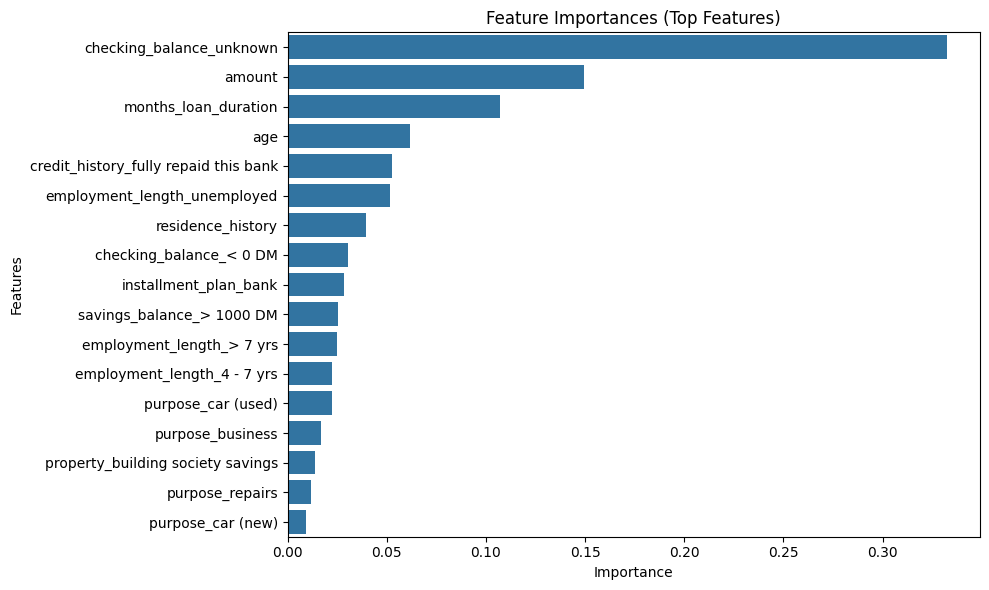

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier

# ============================================================
# 11. 모델 생성 및 학습
# ============================================================
model = DecisionTreeClassifier(
    max_depth=5,
    random_state=SEED  # 기존 전처리 코드의 SEED 상수를 사용합니다.
)

model.fit(X_train_processed, y_train)

# ============================================================
# 12. 전처리 파이프라인에서 변환된 특성 이름 가져오기
# ============================================================
# 원-핫 인코딩 등으로 늘어난 전체 특성의 이름을 자동으로 추출합니다.
feature_names = preprocessor.get_feature_names_out()

# 모델에서 특성 중요도 추출
importance = model.feature_importances_

# ============================================================
# 13. 중요도 데이터프레임 생성 및 정렬
# ============================================================
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

# 중요도가 높은 순서대로 정렬합니다.
fi_df = fi_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# 접두어(num__, cat__)를 제거하여 보기 좋게 다듬습니다.
fi_df['Feature'] = fi_df['Feature'].str.replace('num__', '').str.replace('cat__', '')

# ============================================================
# 14. 결과 출력
# ============================================================
print("🏆 [특성 중요도 순위]")
print("-" * 40)
for index, row in fi_df.iterrows():
    # 중요도가 0인 변수는 제외하고 출력하고 싶다면 조건문을 추가해도 됩니다.
    print(f"{row['Feature']:<30} {row['Importance']:.4f}")
print("-" * 40)

# 가장 중요한 변수 추출
top_feature = fi_df.iloc[0]['Feature']
top_score = fi_df.iloc[0]['Importance']
print(f"\n📢 가장 중요한 변수는 [{top_feature}]이며, 중요도는 {top_score:.4f}입니다.")

# ============================================================
# 15. (선택 사항) 특성 중요도 시각화
# ============================================================
plt.figure(figsize=(10, 6))
# 중요도가 0보다 큰 상위 변수들만 그래프로 그립니다.
sns.barplot(x='Importance', y='Feature', data=fi_df[fi_df['Importance'] > 0])
plt.title('Feature Importances (Top Features)')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

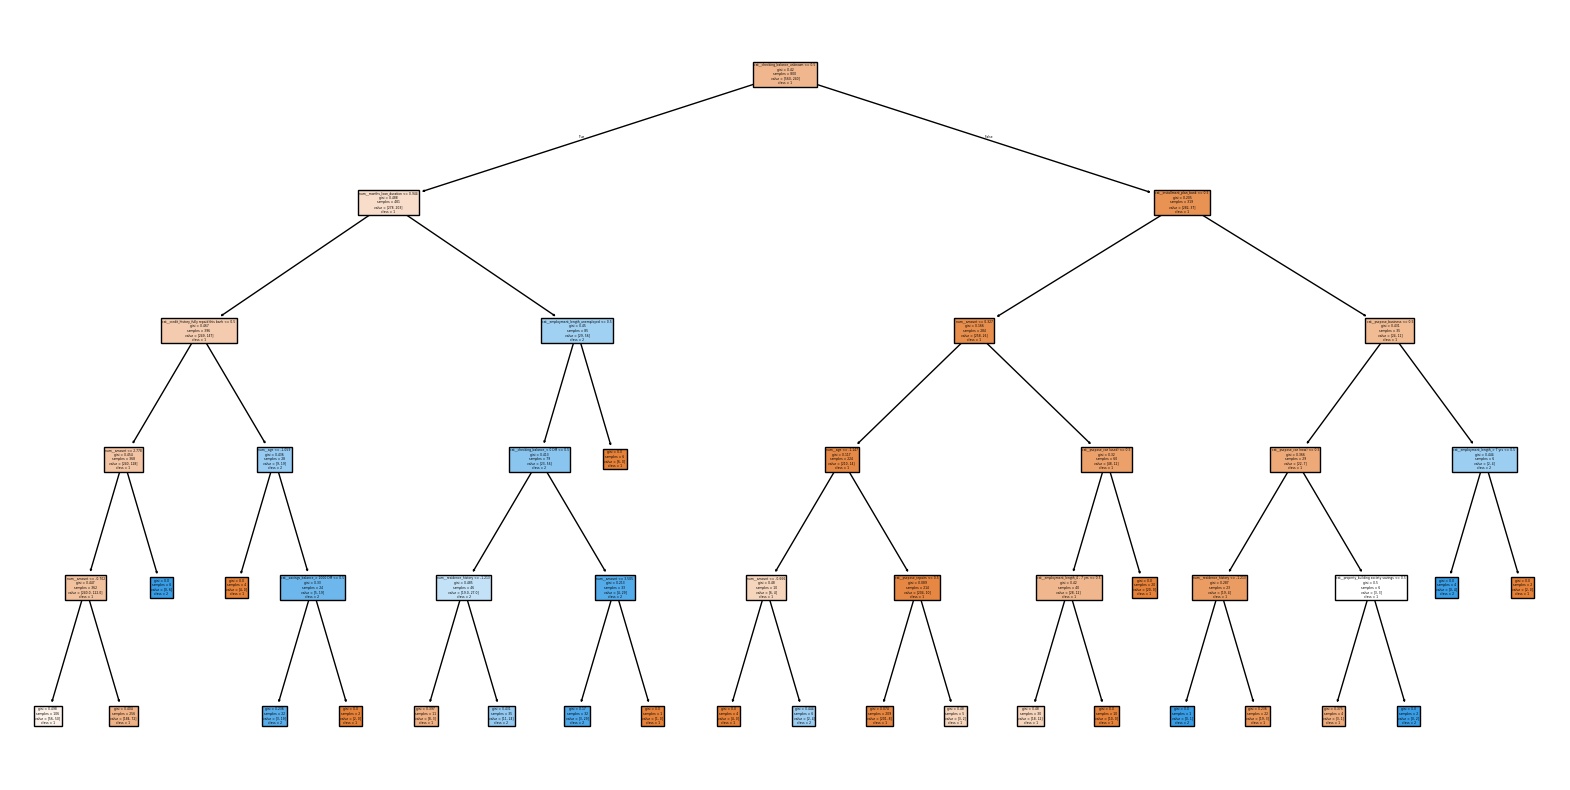

In [26]:
class_names = [str(cls) for cls in label_encoder.classes_]

from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=feature_names,
    class_names=class_names,
    filled=True
)

plt.show()

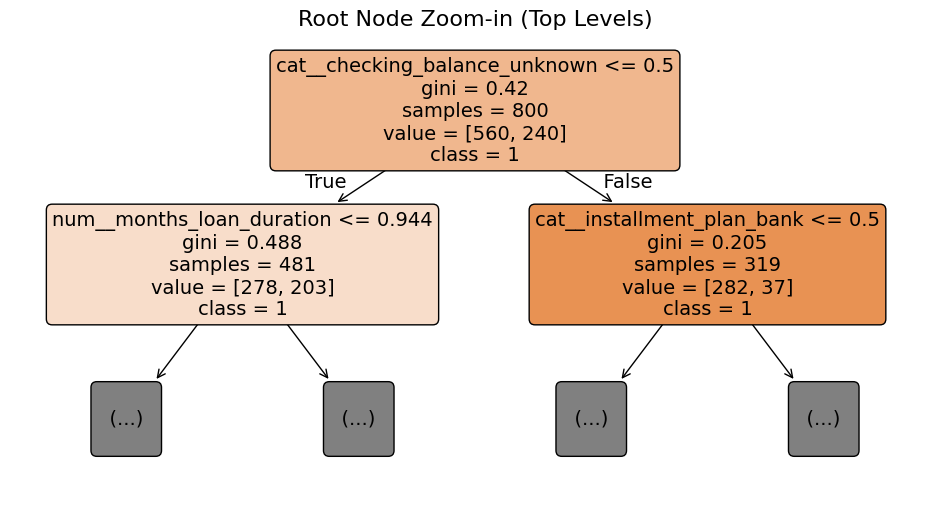

In [27]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# 중요: figsize를 크게 잡고, max_depth=1로 설정하여 상위 노드만 확대합니다.
plt.figure(figsize=(12, 6))

plot_tree(
    model,
    max_depth=1,             # 전체 트리 중 루트 노드와 그 다음 자식 노드까지만 그립니다.
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=14              # 글자 크기를 크게 키워 가독성을 높입니다.
)

plt.title("Root Node Zoom-in (Top Levels)", fontsize=16)
plt.show()

In [28]:
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

# 1) 범주형 변수 처리: 각 컬럼별로 LabelEncoder를 따로 적용합니다.
for col in categorical_features:
    le = LabelEncoder()

    # 학습 데이터로 규칙을 보며 숫자로 변환 (예: 'Good' -> 0, 'Bad' -> 1)
    X_train_processed[col] = le.fit_transform(X_train[col])

    # 테스트 데이터에 동일한 규칙 적용
    # 단, 테스트 데이터에 처음 보는 범주가 있을 경우 에러를 방지하기 위한 처리입니다.
    test_mapping = {label: idx for idx, label in enumerate(le.classes_)}
    X_test_processed[col] = X_test[col].map(test_mapping).fillna(-1).astype(int)

# 2) 수치형 변수 처리: StandardScaler로 표준화합니다.
scaler = StandardScaler()
X_train_processed[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_processed[numeric_features] = scaler.transform(X_test[numeric_features])

# 3) 데이터 타입 변환 (Scikit-learn 및 PyTorch 호환용)
X_train_processed = X_train_processed.to_numpy().astype(np.float32)
X_test_processed = X_test_processed.to_numpy().astype(np.float32)

print("LabelEncoding 완료 후 학습 입력 크기:", X_train_processed.shape)


# ============================================================
# 10. 모델 학습 및 성능 측정 (LabelEncoder 결과)
# ============================================================
model_le = DecisionTreeClassifier(
    max_depth=5,
    random_state=SEED
)
model_le.fit(X_train_processed, y_train)

# 예측 및 정확도 계산
pred_le = model_le.predict(X_test_processed)
accuracy_le = accuracy_score(y_test, pred_le)

print(f"🎯 LabelEncoder 적용 후 테스트 정확도: {accuracy_le:.4f}")

LabelEncoding 완료 후 학습 입력 크기: (800, 20)
🎯 LabelEncoder 적용 후 테스트 정확도: 0.7300


In [29]:
# 수치형 데이터 전처리: 표준화
numeric_transformer = Pipeline(
    steps=[("scaler", StandardScaler())]
)

# 범주형 데이터 전처리: OneHotEncoder 적용 (기존 LabelEncoder 대체)
categorical_transformer = Pipeline(
    steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))]
)

# 컬럼별 전처리 결합
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# 학습 및 테스트 데이터 전처리 변환
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 희소 행렬을 일반 numpy 배열로 변환
X_train_processed = X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed
X_test_processed = X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed


# ============================================================
# 10. 모델 학습 및 성능 측정 (OneHotEncoder 결과)
# ============================================================
model_ohe = DecisionTreeClassifier(
    max_depth=5,
    random_state=SEED
)
model_ohe.fit(X_train_processed, y_train)

# 예측 및 정확도 계산
pred_ohe = model_ohe.predict(X_test_processed)
accuracy_ohe = accuracy_score(y_test, pred_ohe)


# ============================================================
# 11. 결과 출력
# ============================================================
print("\n" + "="*40)
print("📊 Encoding 방식별 정확도 비교")
print("="*40)
# 기존 LabelEncoder 정확도는 기존 테스트 결과를 숫자로 직접 적어주시거나 변수를 연동하시면 됩니다.
print(f"OneHotEncoder  | Accuracy : {accuracy_ohe:.4f}")
print(f"LabelEncoder  | Accuracy : {accuracy_le:.4f}")
print("="*40)


📊 Encoding 방식별 정확도 비교
OneHotEncoder  | Accuracy : 0.7100
LabelEncoder  | Accuracy : 0.7300
